Importing plotly failed. Interactive plots will not work.
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_42304/886711669.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_42304/886711669.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].mean().to_frame()
13:05:43 - cmdstanpy - INFO - Chain [1] start processing
13:05:43 - cmdstanpy - INFO - Chain [1] done processing
13:05:43 - cmdstanpy - INFO - Chain [1] start processing
13:05:43 - cmdstanpy - INFO - Chain [1] done processing
13:05:43 - cmdstanpy - INFO - Chain [1] start processing
13:05:43 - cmdstanpy - INFO - Chain [1] done processing



=== PROPHET – OFF‑shore TEST METRICS ===
Monthly  MSE=117,781,694,146.01  RMSE=343,193.38  MAE=256,166.91  R²=0.2270  MAPE=13.86%
Weekly   MSE=741,619,694,577.55  RMSE=861,173.44  MAE=697,501.44  R²=-0.0672  MAPE=66.06%
Daily    MSE=1,569,036,042,582.33  RMSE=1,252,611.69  MAE=1,142,380.22  R²=-0.1521  MAPE=355.97%


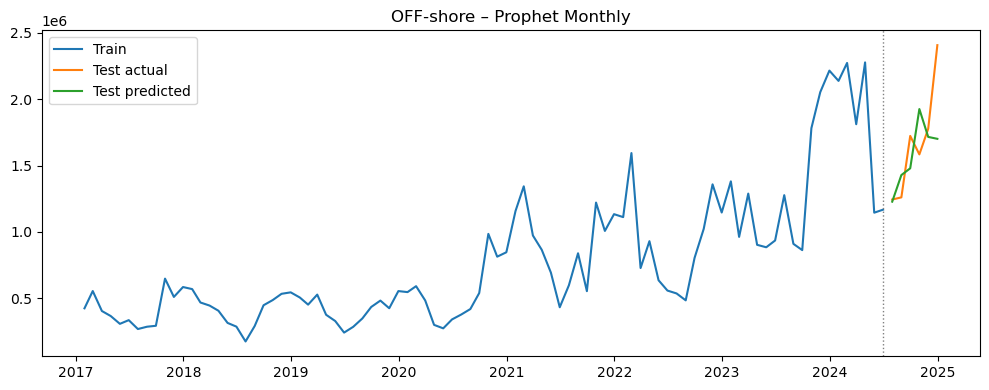

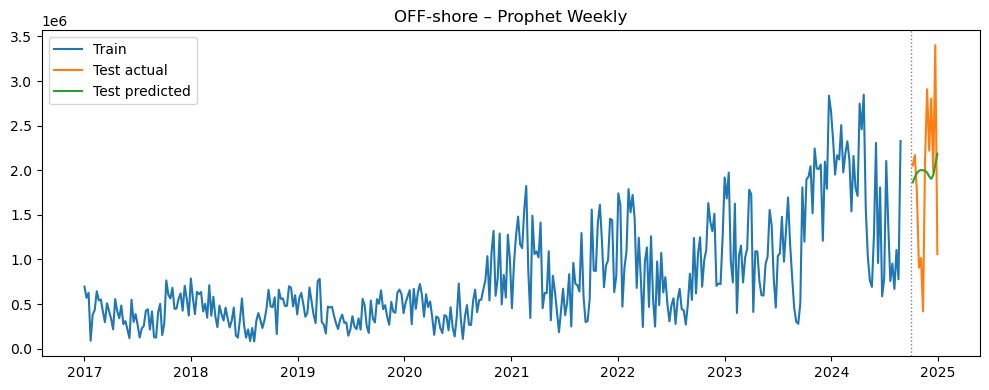

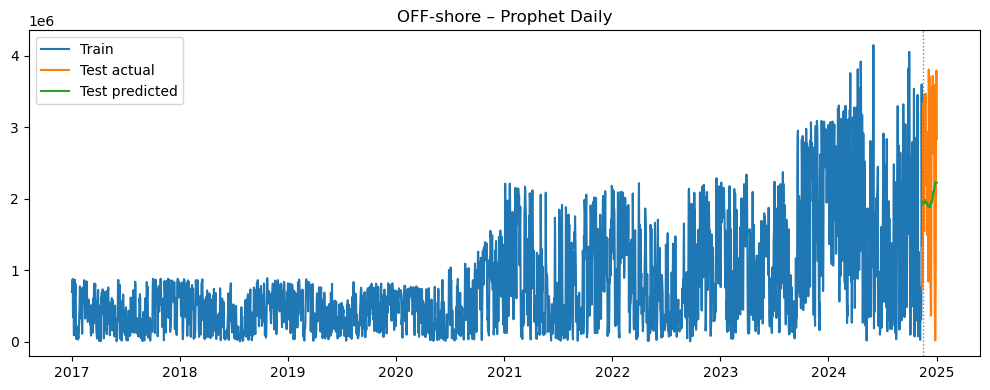

In [1]:
# ================================================================
#  PROPHET  –  Monthly / Weekly / Daily
# ================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet

DATA_PATH = "/Users/polina/Watts-next/data/final_offshore_data_2017_2025.csv" 
SITE      = "OFF‑shore" 

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"]  = df["hour_str"].astype(int) - 1
df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]     = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATE ---------------------------------------------------------
def make_agg(rule):
    g = df.resample(rule)["y"].mean().to_frame()
    g["ds"] = g.index
    return g.reset_index(drop=True)

df_M, df_W, df_D = map(make_agg, ["M", "W", "D"])

# 3) SPLIT -----------------------------------------------------
def split(df_, train_end, val_start, val_end, test_start, test_end):
    tr  = df_[df_.ds <= train_end].copy()
    val = df_[(df_.ds >= val_start) & (df_.ds < val_end)].copy()
    te  = df_[(df_.ds >= test_start) & (df_.ds < test_end)].copy()
    return tr, val, te

m_tr, m_val, m_te = split(df_M, "2024-06-30", "2024-01-01", "2024-07-01",
                                    "2024-07-01", "2025-01-01")
w_tr, w_val, w_te = split(df_W, "2024-08-31", "2024-07-01", "2024-10-01",
                                    "2024-10-01", "2025-01-01")
d_tr, d_val, d_te = split(df_D, "2024-11-13", "2024-10-02", "2024-11-13",
                                    "2024-11-13", "2025-01-12")

# 4) TRAIN -------------------------------------------------------------
model_M = Prophet(yearly_seasonality=True).fit(m_tr[["ds","y"]])
model_W = Prophet(yearly_seasonality=True).fit(w_tr[["ds","y"]])
model_D = Prophet(yearly_seasonality=True, weekly_seasonality=True).fit(d_tr[["ds","y"]])

# 5) PREDICT + METRICS -------------------------------------------------
def mape(a,f): return np.mean(np.abs((a-f)/(a+1e-6)))*100
def eval(model, test_df):
    fc = model.predict(test_df[["ds"]])[["ds","yhat"]]
    merged = test_df.merge(fc, on="ds")
    y, yhat = merged.y.values, merged.yhat.values
    mse  = mean_squared_error(y,yhat); rmse=np.sqrt(mse)
    return mse, rmse, mean_absolute_error(y,yhat), r2_score(y,yhat), mape(y,yhat)

metrics_M = eval(model_M, m_te)
metrics_W = eval(model_W, w_te)
metrics_D = eval(model_D, d_te)

print("\n=== PROPHET –", SITE, "TEST METRICS ===")
for lbl,m in zip(["Monthly","Weekly","Daily"], [metrics_M,metrics_W,metrics_D]):
    mse,rmse,mae,r2,mape = m
    print(f"{lbl:<7}  MSE={mse:,.2f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}  R²={r2:.4f}  MAPE={mape:,.2f}%")

# 6) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title, vline):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(fc["ds"], fc["yhat"], label="Test predicted")
    plt.axvline(pd.to_datetime(vline), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te,
         model_M.predict(m_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Monthly", "2024-07-01")
plot_one(w_tr, w_te,
         model_W.predict(w_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Weekly",  "2024-10-01")
plot_one(d_tr, d_te,
         model_D.predict(d_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Daily",   "2024-11-15")
# ================================================================


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_42304/2574699049.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_42304/2574699049.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].mean().to_frame()
13:05:51 - cmdstanpy - INFO - Chain [1] start processing
13:05:51 - cmdstanpy - INFO - Chain [1] done processing
13:05:51 - cmdstanpy - INFO - Chain [1] start processing
13:05:51 - cmdstanpy - INFO - Chain [1] done processing
13:05:51 - cmdstanpy - INFO - Chain [1] start processing
13:05:52 - cmdstanpy - INFO - Chain [1] done processing



=== PROPHET – ON‑shore TEST METRICS ===
Monthly  MSE=146,740,968,702.83  RMSE=383,067.84  MAE=333,167.48  R²=0.0551  MAPE=18.70%
Weekly   MSE=967,559,384,228.97  RMSE=983,645.96  MAE=779,669.10  R²=-0.1314  MAPE=75.28%
Daily    MSE=1,847,613,681,970.22  RMSE=1,359,269.54  MAE=1,233,757.13  R²=-0.0842  MAPE=381.61%


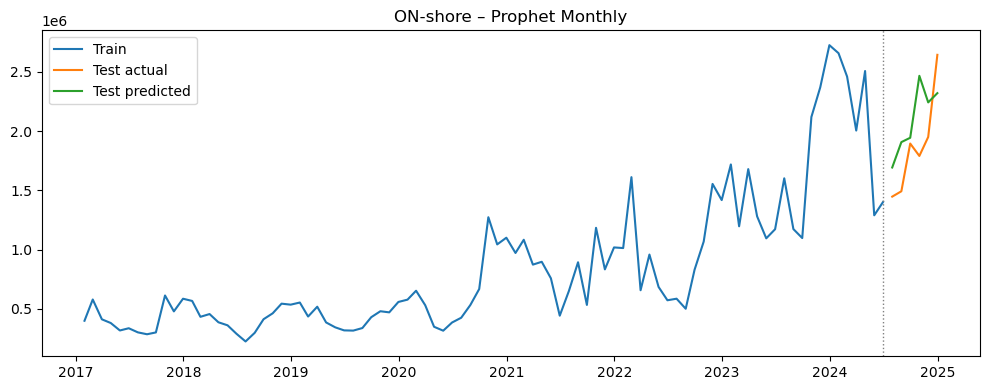

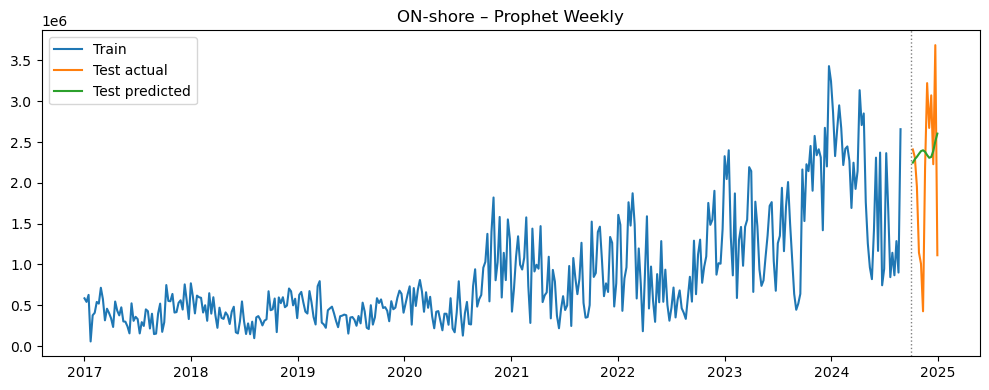

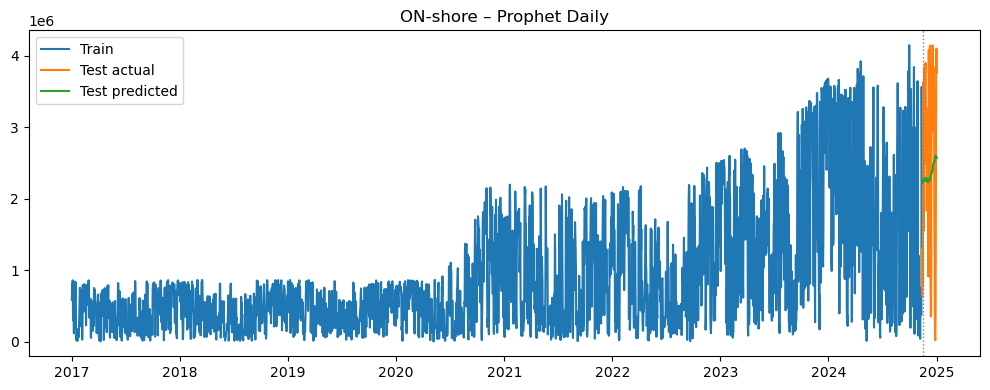

In [2]:
# ================================================================
#  PROPHET  –  Monthly / Weekly / Daily
# ================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet

DATA_PATH = "/Users/polina/Watts-next/data/final_onshore_data_2017_2025.csv" 
SITE      = "ON‑shore" 

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"]  = df["hour_str"].astype(int) - 1
df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]     = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATE ---------------------------------------------------------
def make_agg(rule):
    g = df.resample(rule)["y"].mean().to_frame()
    g["ds"] = g.index
    return g.reset_index(drop=True)

df_M, df_W, df_D = map(make_agg, ["M", "W", "D"])

# 3) SPLIT -----------------------------------------------------
def split(df_, train_end, val_start, val_end, test_start, test_end):
    tr  = df_[df_.ds <= train_end].copy()
    val = df_[(df_.ds >= val_start) & (df_.ds < val_end)].copy()
    te  = df_[(df_.ds >= test_start) & (df_.ds < test_end)].copy()
    return tr, val, te

m_tr, m_val, m_te = split(df_M, "2024-06-30", "2024-01-01", "2024-07-01",
                                    "2024-07-01", "2025-01-01")
w_tr, w_val, w_te = split(df_W, "2024-08-31", "2024-07-01", "2024-10-01",
                                    "2024-10-01", "2025-01-01")
d_tr, d_val, d_te = split(df_D, "2024-11-13", "2024-10-02", "2024-11-13",
                                    "2024-11-13", "2025-01-12")

# 4) TRAIN -------------------------------------------------------------
model_M = Prophet(yearly_seasonality=True).fit(m_tr[["ds","y"]])
model_W = Prophet(yearly_seasonality=True).fit(w_tr[["ds","y"]])
model_D = Prophet(yearly_seasonality=True, weekly_seasonality=True).fit(d_tr[["ds","y"]])

# 5) PREDICT + METRICS -------------------------------------------------
def mape(a,f): return np.mean(np.abs((a-f)/(a+1e-6)))*100
def eval(model, test_df):
    fc = model.predict(test_df[["ds"]])[["ds","yhat"]]
    merged = test_df.merge(fc, on="ds")
    y, yhat = merged.y.values, merged.yhat.values
    mse  = mean_squared_error(y,yhat); rmse=np.sqrt(mse)
    return mse, rmse, mean_absolute_error(y,yhat), r2_score(y,yhat), mape(y,yhat)

metrics_M = eval(model_M, m_te)
metrics_W = eval(model_W, w_te)
metrics_D = eval(model_D, d_te)

print("\n=== PROPHET –", SITE, "TEST METRICS ===")
for lbl,m in zip(["Monthly","Weekly","Daily"], [metrics_M,metrics_W,metrics_D]):
    mse,rmse,mae,r2,mape = m
    print(f"{lbl:<7}  MSE={mse:,.2f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}  R²={r2:.4f}  MAPE={mape:,.2f}%")

# 6) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title, vline):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(fc["ds"], fc["yhat"], label="Test predicted")
    plt.axvline(pd.to_datetime(vline), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te,
         model_M.predict(m_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Monthly", "2024-07-01")
plot_one(w_tr, w_te,
         model_W.predict(w_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Weekly",  "2024-10-01")
plot_one(d_tr, d_te,
         model_D.predict(d_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Daily",   "2024-11-15")
# ================================================================


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from scipy import signal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor
from sktime.forecasting.compose import EnsembleForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.forecasting.compose import make_reduction
from sklearn.ensemble import RandomForestRegressor
from matplotlib.dates import DateFormatter

np.random.seed(42)

In [5]:
# Load the data
db_offshore = pd.read_csv('data/final_offshore_data_2017_2025.csv')
db_onshore = pd.read_csv('data/final_onshore_data_2017_2025.csv')

In [6]:
# Write the function to engineer datetime features
def transform_datetime_features(df, correct_days_column='correct_days', start_date='2017-01-01'):

    df = df.copy()
    
    # Split into 'date' and 'hour'
    df[['date', 'hour']] = df[correct_days_column].str.rsplit('-', n=1, expand=True)
    
    # Create datetime column
    df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'].astype(int) - 1, unit='h')
    
    # Extract month
    df['month'] = df['datetime'].dt.to_period('M').astype(str)
    
    # Calculate week number
    start_date = pd.Timestamp(start_date)
    df['week_number'] = ((df['datetime'] - start_date).dt.days // 7) + 1
    
    return df

# Apply the function to both datasets

db_offshore = transform_datetime_features(db_offshore)
db_onshore = transform_datetime_features(db_onshore)

# Drop datetime 2025-01-01 and set datetime as index
db_offshore = db_offshore[db_offshore['datetime'] != '2025-01-01']
db_onshore = db_onshore[db_onshore['datetime'] != '2025-01-01']

db_offshore.set_index('datetime', inplace=True)
db_onshore.set_index('datetime', inplace=True)

# ##### Offshore data
# Convert hourly data to monthly data
db_off_monthly = db_offshore.groupby('month').mean(numeric_only=True)

train_db_m_off = db_off_monthly[db_off_monthly.index <= '2024-06']
test_db_m_off = db_off_monthly[db_off_monthly.index > '2024-06']

# Convert hourly data to weekly data
db_off_weekly = db_offshore.groupby('week_number').mean(numeric_only=True)

train_db_w_off = db_off_weekly[db_off_weekly.index <= 406]
test_db_w_off = db_off_weekly[db_off_weekly.index > 406]

# Convert hourly data to daily data
db_offshore['date'] = pd.to_datetime(db_offshore['date'], format='%Y-%m-%d')
db_off_daily = db_offshore.groupby('date').mean(numeric_only=True)
db_off_daily.index = pd.to_datetime(db_off_daily.index)

train_db_d_off = db_off_daily[db_off_daily.index <= '2024-11-01']
test_db_d_off = db_off_daily[db_off_daily.index > '2024-11-01']

# Set hourly data
db_off_hourly = db_offshore

# Split into train and test set
train_db_h_off = db_off_hourly[db_off_hourly['date'] <= '2024-12-22']
test_db_h_off = db_off_hourly[db_off_hourly['date'] > '2024-12-22']

# ##### Onshore data

# Convert hourly data to monthly data
db_on_monthly = db_onshore.groupby('month').mean(numeric_only=True)

train_db_m_on = db_on_monthly[db_on_monthly.index <= '2024-06']
test_db_m_on = db_on_monthly[db_on_monthly.index > '2024-06']

# Convert hourly data to weekly data
db_on_weekly = db_onshore.groupby('week_number').mean(numeric_only=True)

train_db_w_on = db_on_weekly[db_on_weekly.index <= 406]
test_db_w_on = db_on_weekly[db_on_weekly.index > 406]

# Convert hourly data to daily data
db_onshore['date'] = pd.to_datetime(db_onshore['date'], format='%Y-%m-%d')
db_on_daily = db_onshore.groupby('date').mean(numeric_only=True)
db_on_daily.index = pd.to_datetime(db_on_daily.index)

train_db_d_on = db_on_daily[db_on_daily.index <= '2024-11-01']
test_db_d_on = db_on_daily[db_on_daily.index > '2024-11-01']

# Set hourly data
db_on_hourly = db_onshore

# Split into train and test set
train_db_h_on = db_on_hourly[db_on_hourly['date'] <= '2024-12-22']
test_db_h_on = db_on_hourly[db_on_hourly['date'] > '2024-12-22']

# ### SARIMAX models
# #### Offshore data

def fit_predict_plot_sarimax(train_db, test_db, target_var, exclude_cols=None,
                             order=(3,1,0), seasonal_periods=12):
    if exclude_cols is None:
        exclude_cols = []

    # 1. Prepare exogenous variables
    drop_cols = [col for col in [target_var] + exclude_cols if col in train_db.columns]
    exog_vars = train_db.columns.drop(drop_cols)
    exog_feature_names = exog_vars.tolist()

    scaler = StandardScaler()
    train_exog_scaled = scaler.fit_transform(train_db[exog_vars])
    test_exog_scaled = scaler.transform(test_db[exog_vars])

    # 2. Define seasonal_order based on provided seasonal_periods
    seasonal_order = (1, 1, 1, seasonal_periods)

    # 3. Fit SARIMAX model
    model = SARIMAX(
        train_db[target_var],
        exog=train_exog_scaled,
        order=order,
        seasonal_order=seasonal_order
    )
    model_fit = model.fit(disp=True)

    # 4. Get t-statistics of exogenous coefficients
    exog_coeffs = model_fit.params[model_fit.model.exog_names]
    exog_t_stats = (exog_coeffs / model_fit.bse[model_fit.model.exog_names]).sort_values(ascending=False)

    # 5. Make predictions
    predictions = model_fit.predict(
        start=len(train_db[target_var]),
        end=len(train_db[target_var]) + len(test_db[target_var]) - 1,
        exog=test_exog_scaled,
        dynamic=False
    )

    return model_fit, predictions, exog_t_stats

# ##### Monthly data

model_fit_m_off, predictions_m_off, t_stats_m_off = fit_predict_plot_sarimax(
train_db=train_db_m_off,
test_db=test_db_m_off,
target_var='volume',
exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
order=(3,1,1),
seasonal_periods=12
)


# ##### Weekly data

# Retrieve exogenous variables
exog_vars = train_db_w_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_off[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_off[exog_vars])

# Fit the model
model = SARIMAX(
train_db_w_off['volume'],
exog=train_exog_scaled_w,
order=(3,1,0),  # ARIMA components
seasonal_order=(1,1,1,52)  # Seasonal components
)
model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_w_off = model_fit.predict(
start=len(train_db_w_off['volume']),
end=len(train_db_w_off['volume']) + len(test_db_w_off['volume']) - 1,
exog=test_exog_scaled_w,
dynamic=False)

# Filter 2024 data
#train_subset = train_db_w_off[train_db_w_off.index >= 300]
#test_subset = test_db_w_off[test_db_w_off.index >= 300]
##pred_subset = predictions[predictions.index >= 300]


# ##### Daily data

# Retrieve exogenous variables
exog_vars = train_db_d_off.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_off[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_off[exog_vars])

# Alternative approach:
stl = STL(train_db_d_off['volume'], period=365)
result = stl.fit()
train_db_d_off['deseasonalized'] = train_db_d_off['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
train_db_d_off['deseasonalized'],
exog=train_exog_scaled_d,
order=(3,1,0),
seasonal_order=(1,1,1,30)
)  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_d_off = model_fit.predict(
start=len(train_db_d_off['volume']),
end=len(train_db_d_off['volume']) + len(test_db_d_off['volume']) - 1,
exog=test_exog_scaled_d,
dynamic=False)

# Filter 2024 data
# train_subset = train_db_d_off[train_db_d_off.index >= "2024-01-01"]
# test_subset = test_db_d_off[test_db_d_off.index >= "2024-01-01"]
# pred_subset = predictions[predictions.index >= "2024-01-01"]

# #### Onshore data

# ##### Monthly data

model_fit_m_on, predictions_m_on, t_stats_m_on = fit_predict_plot_sarimax(
train_db=train_db_m_on,
test_db=test_db_m_on,
target_var='volume',
exclude_cols=['capacity', 'week_number', 'percentage', 'wind_speed_avg_10'],
order=(3,1,1),
seasonal_periods=12
)


# ##### Weekly data

# Retrieve exogenous variables
exog_vars = train_db_w_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_w = scaler.fit_transform(train_db_w_on[exog_vars])
test_exog_scaled_w = scaler.transform(test_db_w_on[exog_vars])

# Fit the model
model = SARIMAX(
train_db_w_on['volume'],
exog=train_exog_scaled_w,
order=(3,1,0),  # ARIMA components
seasonal_order=(1,1,1,52)  # Seasonal components
)
model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_w_on = model_fit.predict(
start=len(train_db_w_on['volume']),
end=len(train_db_w_on['volume']) + len(test_db_w_on['volume']) - 1,
exog=test_exog_scaled_w,
dynamic=False)

# ##### Daily data

# Retrieve exogenous variables
exog_vars = train_db_d_on.columns.drop(['volume', 'wind_speed_avg_10', 'percentage', 'capacity', 'week_number'])

# Standartise variables
scaler = StandardScaler()
train_exog_scaled_d = scaler.fit_transform(train_db_d_on[exog_vars])
test_exog_scaled_d = scaler.transform(test_db_d_on[exog_vars])

# Alternative approach:
stl = STL(train_db_d_on['volume'], period=365)
result = stl.fit()
train_db_d_on['deseasonalized'] = train_db_d_on['volume'] - result.seasonal

# Now apply SARIMA to deseasonalized data
model = SARIMAX(
train_db_d_on['deseasonalized'],
exog=train_exog_scaled_d,
order=(3,1,0),
seasonal_order=(1,1,1,30)
)  # Use a smaller seasonal period like 30 (monthly) if needed

model_fit = model.fit(disp=True)

exog_coeffs = model_fit.params[model_fit.model.exog_names]
exog_t_stats = exog_coeffs / model_fit.bse[model_fit.model.exog_names]
exog_t_stats.sort_values(ascending=False)

# Predict
predictions_d_on = model_fit.predict(
start=len(train_db_d_on['volume']),
end=len(train_db_d_on['volume']) + len(test_db_d_on['volume']) - 1,
exog=test_exog_scaled_d,
dynamic=False)

# Filter 2024 data
# train_subset = train_db_d_on[train_db_d_on.index >= "2024-01-01"]
# test_subset = test_db_d_on[test_db_d_on.index >= "2024-01-01"]
# pred_subset = predictions[predictions.index >= "2024-01-01"]

/opt/anaconda3/envs/ml2025/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml2025/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           14     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.78706D+07    |proj g|=  7.88053D+07

At iterate    1    f=  1.14684D+07    |proj g|=  4.89752D+07

At iterate    2    f=  4.99713D+06    |proj g|=  3.93105D+07

At iterate    3    f=  3.34500D+05    |proj g|=  1.24637D+07

At iterate    4    f=  3.01918D+04    |proj g|=  2.55078D+06

At iterate    5    f=  1.99028D+03    |proj g|=  8.51312D+05

At iterate    6    f=  1.59719D+01    |proj g|=  3.31710D+04

At iterate    7    f=  1.18003D+01    |proj g|=  5.53041D+03

At iterate    8    f=  1.16980D+01    |proj g|=  1.30602D+03

At iterate    9    f=  1.16974D+01    |proj g|=  2.13437D+03



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.



At iterate   10    f=  1.16952D+01    |proj g|=  1.56510D+03



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.


...


At iterate    1    f=  1.21120D+01    |proj g|=  3.84685D-02

At iterate    2    f=  1.21074D+01    |proj g|=  3.87482D-02

At iterate    3    f=  1.21008D+01    |proj g|=  2.69341D-02

At iterate    4    f=  1.21003D+01    |proj g|=  1.88450D-02

At iterate    5    f=  1.20998D+01    |proj g|=  2.53240D-03

At iterate    6    f=  1.20998D+01    |proj g|=  3.71820D-04

At iterate    7    f=  1.20998D+01    |proj g|=  1.49549D-04

At iterate    8    f=  1.20998D+01    |proj g|=  1.39547D-04

At iterate    9    f=  1.20998D+01    |proj g|=  1.51500D-05

At iterate   10    f=  1.20998D+01    |proj g|=  8.46788D-07

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/opt/anaconda3/envs/ml2025/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/ml2025/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_42304/1818585072.py:279: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_db_d_on['deseasonalized'] = train_db_d_on['volume'] - result.seasonal
/opt/anaconda3/envs

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           13     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.41143D+01    |proj g|=  7.25353D-02


 This problem is unconstrained.



At iterate    1    f=  1.40969D+01    |proj g|=  1.17539D-01

At iterate    2    f=  1.40748D+01    |proj g|=  7.99484D-02

At iterate    3    f=  1.40694D+01    |proj g|=  3.84903D-02

At iterate    4    f=  1.40664D+01    |proj g|=  1.41217D-02

At iterate    5    f=  1.40655D+01    |proj g|=  6.47828D-03

At iterate    6    f=  1.40650D+01    |proj g|=  5.56034D-03

At iterate    7    f=  1.40645D+01    |proj g|=  1.55139D-02

At iterate    8    f=  1.40637D+01    |proj g|=  1.21960D-03

At iterate    9    f=  1.40636D+01    |proj g|=  1.06709D-03

At iterate   10    f=  1.40636D+01    |proj g|=  7.34839D-04

At iterate   11    f=  1.40636D+01    |proj g|=  1.37290D-03

At iterate   12    f=  1.40635D+01    |proj g|=  1.14488D-04

At iterate   13    f=  1.40635D+01    |proj g|=  1.24736D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates

00:31:50 - cmdstanpy - INFO - Chain [1] start processing
00:31:50 - cmdstanpy - INFO - Chain [1] done processing


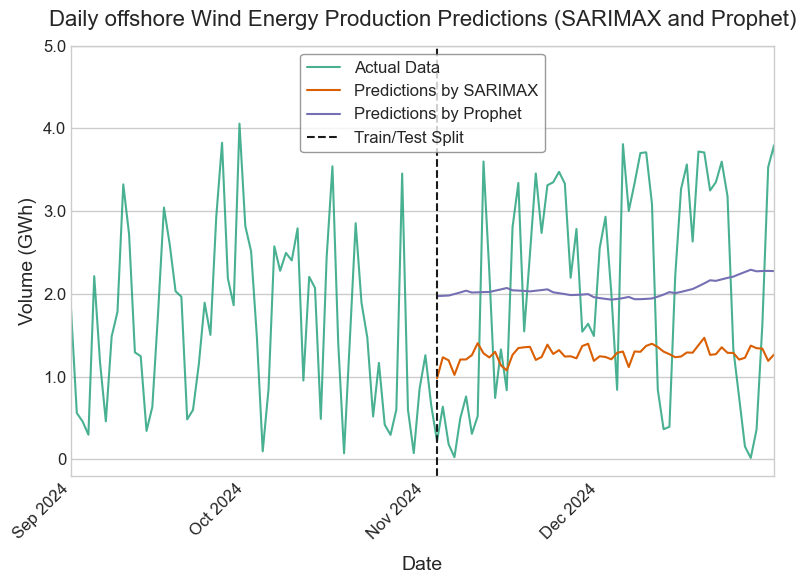

00:31:50 - cmdstanpy - INFO - Chain [1] start processing
00:31:50 - cmdstanpy - INFO - Chain [1] done processing


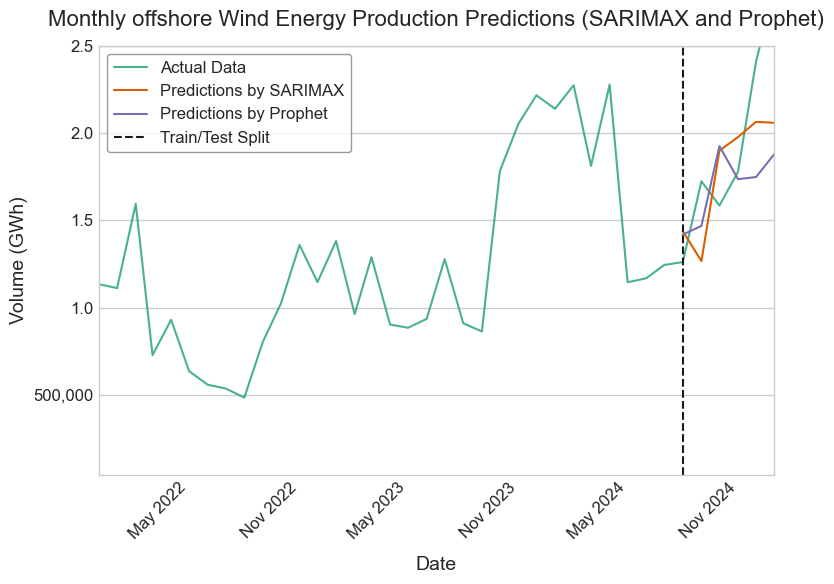

00:32:39 - cmdstanpy - INFO - Chain [1] start processing
00:32:39 - cmdstanpy - INFO - Chain [1] done processing


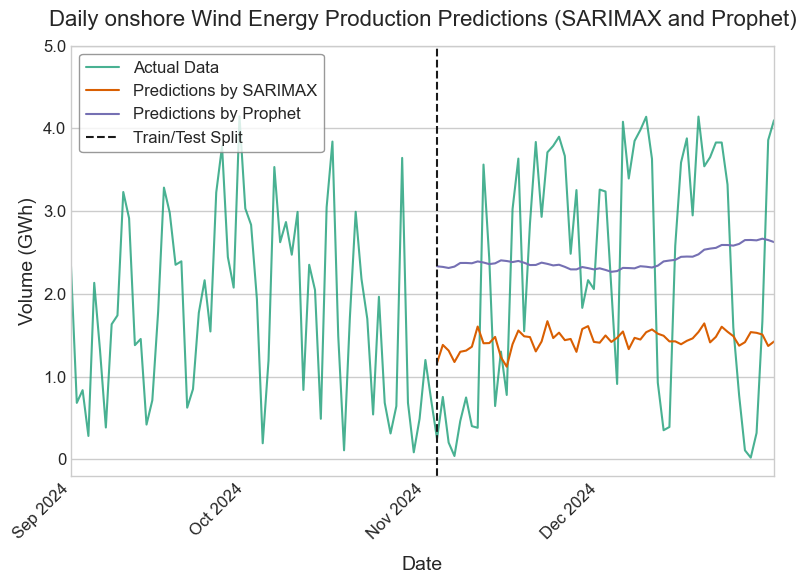

00:32:40 - cmdstanpy - INFO - Chain [1] start processing
00:32:40 - cmdstanpy - INFO - Chain [1] done processing


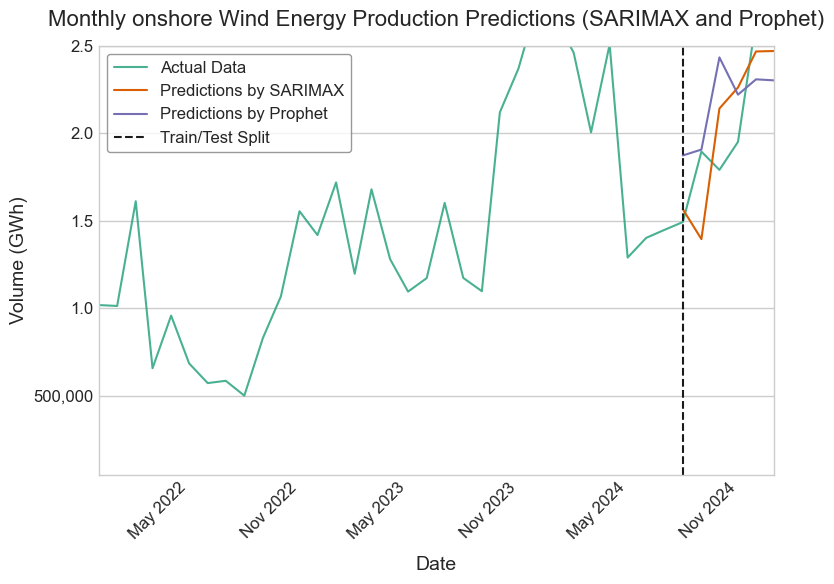

✅ All plots saved in: /Users/polina/Watts-next/plots


In [23]:
# ================================================================
# 0. Imports & global Matplotlib style
# ================================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from pathlib import Path

# Use the legacy “seaborn-whitegrid” look no matter the Matplotlib version
try:
    plt.style.use("seaborn-v0_8-whitegrid")     # Matplotlib ≥ 3.8
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")      # Matplotlib ≤ 3.7
    except OSError:
        import seaborn as sns                   # Fallback: call seaborn directly
        sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["savefig.dpi"]    = 300


# ================================================================
# 1. Helper functions
# ================================================================
def millions(x, _):
    """Formatter: 1 500 000 → 1.5 (used for the Y-axis ticks)."""
    return f"{x/1_000_000:.1f}" if abs(x) >= 1_000_000 else f"{x:,.0f}"


def load_raw(csv_path: str) -> pd.DataFrame:
    """
    Read a CSV that contains ‘correct_days’ (yyyy-mm-dd-HH) and ‘volume’.
    Return a tidy DataFrame with columns  ds  (datetime) and  y  (target),
    sorted by time.
    """
    df = pd.read_csv(csv_path)
    # Split 'correct_days' into date and hour
    df[["date", "hour"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
    # Convert to proper pandas datetime
    df["ds"] = (pd.to_datetime(df["date"]) +
                pd.to_timedelta(df["hour"].astype(int) - 1, unit="h"))
    df["y"] = df["volume"]
    return df.sort_values("ds")[["ds", "y"]]


def resample(df: pd.DataFrame, rule: str) -> pd.DataFrame:
    """Aggregate to daily ('D') or month-start ('MS') mean."""
    g = df.set_index("ds").y.resample(rule).mean().to_frame()
    g["ds"] = g.index
    return g.reset_index(drop=True)


def split(df: pd.DataFrame, n_test: int):
    """Return (train_df, test_df) where the last n_test rows are the test set."""
    return df.iloc[:-n_test].copy(), df.iloc[-n_test:].copy()


def prophet_fit(train_df: pd.DataFrame) -> Prophet:
    """Fit Prophet; enable weekly seasonality only for daily time series."""
    is_daily = train_df.ds.diff().dropna().mode()[0] == pd.Timedelta(days=1)
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=is_daily,
        daily_seasonality=False
    )
    return model.fit(train_df[["ds", "y"]])


def prophet_forecast(model: Prophet, test_df: pd.DataFrame) -> pd.Series:
    """Return a Series with Prophet forecasts indexed by the test dates."""
    fc = model.predict(test_df[["ds"]])["yhat"]
    fc.index = test_df.ds
    return fc


def sarimax_forecast(train_df, test_df, seas):
    """Fit SARIMAX and forecast exactly the length of the test set."""
    model = SARIMAX(
        train_df.y,
        order=(3, 1, 1),
        seasonal_order=seas,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    fc = res.get_prediction(
        start=len(train_df),
        end=len(train_df) + len(test_df) - 1
    ).predicted_mean
    fc.index = test_df.ds
    return fc


def plot_like_example(full_df, test_df,
                      sarimax_series, prophet_series,
                      split_date, title,
                      freq, xlim, ylim_top, out_path):
    """Render one figure in exactly the same visual style as your reference."""
    fig, ax = plt.subplots()

    # 1) Actual data (entire history)
    ax.plot(full_df.ds, full_df.y,
            label="Actual Data", color="#1b9e77", alpha=0.8)

    # 2) SARIMAX curve (only the test window)
    ax.plot(sarimax_series.index, sarimax_series.values,
            label="Predictions by SARIMAX", color="#d95f02")

    # 3) Prophet curve (only the test window)
    ax.plot(prophet_series.index, prophet_series.values,
            label="Predictions by Prophet", color="#7570b3")

    # Train / test split marker
    ax.axvline(pd.to_datetime(split_date), color="k", ls="--",
               label="Train/Test Split")

    # Titles and labels
    ax.set_title(title, pad=14, fontsize=16)
    ax.set_xlabel("Date", labelpad=10, fontsize=14)
    ax.set_ylabel("Volume (GWh)", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)

    # Grid only on the X axis
    ax.grid(axis="x")

    # Legend box styling
    ax.legend(loc="best", fontsize=12,
              frameon=True, facecolor="white",
              edgecolor="grey", fancybox=True, framealpha=0.8)

    # X-axis tick layout (6-month steps for Monthly, 1-month for Daily)
    if freq == "M":
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    else:  # Daily
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    fig.autofmt_xdate(rotation=45)

    # Apply hard limits to the X and Y axes
    ax.set_xlim(pd.to_datetime(xlim[0]), pd.to_datetime(xlim[1]))
    ax.set_ylim(top=ylim_top)

    # Format Y-axis numbers in “millions”
    ax.yaxis.set_major_formatter(FuncFormatter(millions))

    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()


# ================================================================
# 2. Paths, test-window sizes, axis limits
# ================================================================
CSV = {
    "OFF": "data/final_offshore_data_2017_2025.csv",
    "ON":  "data/final_onshore_data_2017_2025.csv",
}
SAVE_DIR = Path("plots")
SAVE_DIR.mkdir(exist_ok=True)

TEST_ROWS = {"D": 60, "M": 6}                # 60 days for Daily, 6 months for Monthly
XLIM_M = ("2021-12-01", "2024-12-31")        # Monthly window
XLIM_D = ("2024-09-01", "2024-12-31")        # Daily window
YLIM_M = 2_500_000                           # Upper Y limit for Monthly plots
YLIM_D = 5_000_000                           # Upper Y limit for Daily plots


# ================================================================
# 3. Main loop – generates four PNG files
# ================================================================
for tag, path in CSV.items():
    raw = load_raw(path)

    # ---------- DAILY ----------
    df_daily = resample(raw, "D")
    tr_d, te_d = split(df_daily, TEST_ROWS["D"])
    sar_d = sarimax_forecast(tr_d, te_d, seas=(1, 1, 1, 30))
    prp_d = prophet_forecast(prophet_fit(tr_d), te_d)

    plot_like_example(
        full_df=df_daily, test_df=te_d,
        sarimax_series=sar_d, prophet_series=prp_d,
        split_date=te_d.ds.min(),
        title=f"Daily {tag.lower()}shore Wind Energy Production "
              f"Predictions (SARIMAX and Prophet)",
        freq="D",
        xlim=XLIM_D,
        ylim_top=YLIM_D,
        out_path=SAVE_DIR / f"{tag.lower()}_daily.png"
    )

    # ---------- MONTHLY ----------
    df_month = resample(raw, "MS")
    tr_m, te_m = split(df_month, TEST_ROWS["M"])
    sar_m = sarimax_forecast(tr_m, te_m, seas=(1, 1, 1, 12))
    prp_m = prophet_forecast(prophet_fit(tr_m), te_m)

    plot_like_example(
        full_df=df_month, test_df=te_m,
        sarimax_series=sar_m, prophet_series=prp_m,
        split_date=te_m.ds.min(),
        title=f"Monthly {tag.lower()}shore Wind Energy Production "
              f"Predictions (SARIMAX and Prophet)",
        freq="M",
        xlim=XLIM_M,
        ylim_top=YLIM_M,
        out_path=SAVE_DIR / f"{tag.lower()}_monthly.png"
    )

print("✅ All plots saved in:", SAVE_DIR.resolve())
